In [1]:
%cd "D:\\python\\notebooks"
import os
import re
import pandas as pd
import numpy as np

D:\python\notebooks


In [2]:
cabinas_premium=[#Tenian escaleras cerca
"A34","A35","A32","A30","A31","A33","A28","A26","A27","A29",
"B98","B96","B94","B90","B88","B92","B84","B82","B78","B76","B73","B75","B77","B81","B79","B83","B85","B87","B89","B91","B93","B95","B97",
"C94","C96","C92","C90","C88","C86","C84","C82","C80","C148","C146","C144","C142","C140","C138","C136","C134","C132","C130","C127","C125","C123","C121","C119","C127","C125","C123","C89","C87","C85","C83",
"C81","C79","C77","C75","C73","C66","C64","C62","C46","C44","C42","C40","C38","C36","C34","C32","C30","C28","C26","C24","C22","C56","C58","C60","C104","C106","C108","C110","C101","C99","C97","C95","C59",
"C57","C39","C35","C37","C29","C31","C53","C51","C49","C23","C37","C8","C4","C2","C1","C3","C5","C7",
"D89","D81","D87","D85","D83","D77","D79","D75","D80","D76","D82","D78","D84","D86","D88","D62","D56","D66","D64","D61","D55","D34","D35",
"E105","E102","E99","E98","E89","E87","E85","E82","E63","E62","E66","E61","E27","E28","E30","E24","E22","E3","E5","E1","E7","E2","E201",
"F63","F59","F51","F50","F58","F24","F26","F28","F22","F18","F20","F29","F12","F15","F17","F31","F39",
"G20","G18","G19","G16","G10","G8","G6", 
]

In [3]:
def get_extra_data (row,cabinas_premium):
    cabin_to_number={
        "A":0,
        "B":1,
        "C":2,
        "D":3,
        "E":4,
        "F":5,
        "G":6,
        "T":7
    }
    is_miss=0
    is_mrs=0
    is_mr=0
    is_master=0
    is_other=0
    is_nobility=0
    is_rev=0
    is_dr=0
    is_french=0
    is_soldier=0
    is_captain=0
    first_10k=0
    is_prepaid=0
    is_naviera=0
    is_wc=0
    is_agent_a=0
    is_agent_ca=0
    is_agent_sc=0
    is_special=0
    super_cabin=0
    is_Southampton=0
    is_Queenstown=0
    is_Cherbourg=0
    ########NAME
    if "Rev." in row["Name"]:
        is_rev=1
        is_mr=1
        
    elif "Dr." in row["Name"]:
        is_dr=1
        if "female" in row["Sex"]:
            is_miss=1
        elif "male" in row["Sex"]:
            is_mr=1
        else:
            raise Exception("Algo salio mal...")
    elif "Mme." in row["Name"]:
        is_french=1
        is_mrs=1
    elif "Mlle." in row["Name"]:
        is_french=1
        is_miss=1
    elif "Jonkheer." in row["Name"]:
        is_mr=1
        is_french=1
    elif "Capt." in row["Name"]:
        is_mr=1
        is_captain=1
    elif "Col." in row["Name"] or "Major." in row["Name"]:
        is_soldier=1
        is_mr=1
    elif "Lady." in row["Name"] or "Countess." in row["Name"] or "Dona." in row["Name"]:
        is_mrs=1
        is_nobility =1
    elif "Sir." in row["Name"]:
        is_mr=1
        is_nobility=1
    elif "Miss." in row["Name"] or "Ms." in row["Name"]:#solteras
        is_miss=1
    elif "Mr." in row["Name"] or "Don." in row["Name"]:#Hombre Adulto
        is_mr=1
    elif "Mrs." in row["Name"]:#Casados Mujer
        
        is_mrs=1
    elif "Master." in row["Name"]:#Jovenes
        is_master=1
    else:
        print(row["Name"])
        raise Exception("Tiene un titulo raro")
        is_other=1
    ####### Ticket         
    if "PP" in row["Ticket"] or "P.P" in row["Ticket"]:
        is_prepaid =1
    elif "LINE" in row["Ticket"]:
        is_naviera =1
    elif "CA" in row["Ticket"] or "C.A" in row["Ticket"] :
        is_agent_ca = 1
    elif (("A"  in row["Ticket"]  and "." in row["Ticket"]) or "A/" in row["Ticket"]):   
        is_agent_a = 1    
    elif ("SC" in row["Ticket"] or "S.C" in row["Ticket"] ):
        is_agent_sc=1
    elif("W/C" in row["Ticket"] or "W./C" in row["Ticket"]):
        is_wc =1
    elif("SP" in row["Ticket"]  or "S.P" in   row["Ticket"]):
        is_special =1
    if is_naviera==0:   
        try:
            no_ticket=int(row["Ticket"])
        except:
            
            no_ticket=int(row["Ticket"].split(" ")[-1])
    else:
        no_ticket=99_999
        
    if no_ticket <= 10_000:
        first_10k=1
    ###Embarked
    if row["Embarked"] == "Q":
        is_Queenstown =1
    elif row["Embarked"] == "C":
        is_Cherbourg =1
    elif row["Embarked"] == "S":
        is_Southampton = 1
    #Cabin
    if not pd.isna(row["Cabin"]):
        
        if row["Cabin"] in cabinas_premium:
            super_cabin=1
        level=cabin_to_number[row["Cabin"][0]]
    else:
        level=3
    return pd.Series([is_miss,is_mr,is_mrs,is_master,is_nobility,is_rev,is_dr,is_french,is_soldier,is_captain,is_prepaid,is_naviera,is_agent_ca,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,
                      super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level])

In [4]:
def correct_age(row,mean_ladies,mean_married,mean_mr):
    if pd.isna(row["Age"]):
        if row["is_master"]:
            return 6
        elif row["is_miss"]:
            return mean_ladies
        elif row["is_mrs"]:
            return mean_married
        else:
            return mean_mr
            
    else:
        return row["Age"]
    

In [5]:

df = pd.read_csv("./DATASETS/titanic/train.csv",sep=",")
df=df.drop(columns=['PassengerId'])
df[['is_miss',"is_mr","is_mrs","is_master","is_nobility","is_rev","is_dr","is_french","is_soldier","is_captain","is_prepaid","is_naviera",
   "is_agent_ca","is_agent_a","is_agent_sc","is_wc","is_special","first_10k","super_cabin","is_Queenstown","is_Cherbourg","is_Southampton","level"]] = df.apply(get_extra_data, axis=1,result_type="expand",cabinas_premium=cabinas_premium)

just_ladys=df[df['is_miss'] == 1]
just_married_ladies=df[df['is_mrs'] == 1]
just_mr= df[df['is_mr'] == 1]
mean_age_ladies = just_ladys["Age"].mean()
mean_age_mr=just_mr["Age"].mean()
mean_age_married_ladies=just_married_ladies["Age"].mean()
print(mean_age_ladies,mean_age_married_ladies,mean_age_mr)
df["Age"]= df.apply(correct_age, axis=1,mean_ladies=mean_age_ladies,mean_married=mean_age_married_ladies,mean_mr=mean_age_mr)

df.tail()

22.026666666666667 35.873873873873876 32.98441247002398


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level
886,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.00,NaN,...,0,0,0,0,0,0,0,0,1,3
887,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.00,B42,...,0,0,0,0,0,0,0,0,1,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,22.026667,1,2,W./C. 6607,23.45,NaN,...,0,0,1,0,1,0,0,0,1,3
889,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.00,C148,...,0,0,0,0,0,1,0,1,0,2
890,0,3,"Dooley, Mr. Patrick",male,32.000000,0,0,370376,7.75,NaN,...,0,0,0,0,0,0,1,0,0,3


In [6]:
special_tickets=set()
for ticket in df["Ticket"]:
    try:
        aux=int(ticket)
    except:
        special_tickets.add(ticket)
print(special_tickets)

{'A/5. 13032', 'A/5 3536', 'SW/PP 751', 'C.A. 31026', 'A/5 21173', 'PC 17482', 'A/5. 2151', 'PC 17759', 'S.P. 3464', 'SOTON/O.Q. 392087', 'A/5 21174', 'SC/PARIS 2131', 'PC 17592', 'PC 17601', 'SC/PARIS 2149', 'PC 17572', 'C 4001', 'W./C. 14263', 'A/5 3902', 'S.O./P.P. 3', 'STON/O2. 3101290', 'A/5. 10482', 'STON/O 2. 3101274', 'STON/O 2. 3101273', 'C.A. 34260', 'W./C. 6609', 'C.A. 33111', 'STON/O2. 3101283', 'W/C 14208', 'A/5 2466', 'SOTON/OQ 3101316', 'PC 17475', 'PC 17756', 'A/4 45380', 'SOTON/O2 3101287', 'SOTON/OQ 392090', 'A/5 21171', 'A/5 3540', 'STON/O 2. 3101286', 'PC 17760', 'A/5 2817', 'SOTON/O.Q. 3101310', 'SOTON/O.Q. 3101312', 'PC 17755', 'PP 9549', 'F.C.C. 13531', 'C.A. 6212', 'SCO/W 1585', 'PC 17485', 'STON/O2. 3101271', 'STON/O 2. 3101280', 'F.C.C. 13528', 'C.A. 34651', 'A/5 21172', 'A/4. 34244', 'PC 17483', 'SOTON/OQ 392076', 'SC/AH Basle 541', 'A/S 2816', 'STON/O2. 3101279', 'A/5. 851', 'PC 17476', 'W./C. 6608', 'C.A. 33595', 'P/PP 3381', 'C.A. 2673', 'S.C./A.4. 23567',

In [7]:
df=df.drop(columns=['Name',"Sex","Ticket","Cabin","Embarked","is_captain"])
print(df.columns)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'is_miss',
       'is_mr', 'is_mrs', 'is_master', 'is_nobility', 'is_rev', 'is_dr',
       'is_french', 'is_soldier', 'is_prepaid', 'is_naviera', 'is_agent_ca',
       'is_agent_a', 'is_agent_sc', 'is_wc', 'is_special', 'first_10k',
       'super_cabin', 'is_Queenstown', 'is_Cherbourg', 'is_Southampton',
       'level'],
      dtype='str')


In [8]:
#conteo = (df['is_special'] ==1  ).sum()
#filtered_df = df[df['is_other'] == 1]
#print(conteo)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Survived        891 non-null    int64  
 1   Pclass          891 non-null    int64  
 2   Age             891 non-null    float64
 3   SibSp           891 non-null    int64  
 4   Parch           891 non-null    int64  
 5   Fare            891 non-null    float64
 6   is_miss         891 non-null    int64  
 7   is_mr           891 non-null    int64  
 8   is_mrs          891 non-null    int64  
 9   is_master       891 non-null    int64  
 10  is_nobility     891 non-null    int64  
 11  is_rev          891 non-null    int64  
 12  is_dr           891 non-null    int64  
 13  is_french       891 non-null    int64  
 14  is_soldier      891 non-null    int64  
 15  is_prepaid      891 non-null    int64  
 16  is_naviera      891 non-null    int64  
 17  is_agent_ca     891 non-null    int64  
 18  i

In [10]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare,is_miss,is_mr,is_mrs,is_master,...,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,...,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.843003,0.523008,0.381594,32.204208,0.208754,0.602694,0.143659,0.044893,...,0.035915,0.015713,0.011223,0.001122,0.195286,0.052750,0.086420,0.188552,0.722783,2.860831
std,0.486592,0.836071,13.271043,1.102743,0.806057,49.693429,0.406647,0.489615,0.350940,0.207186,...,0.186182,0.124431,0.105403,0.033501,0.396644,0.223659,0.281141,0.391372,0.447876,0.750088
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.000000,3.000000,30.000000,0.000000,0.000000,14.454200,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
75%,1.000000,3.000000,35.873874,1.000000,0.000000,31.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [11]:
import matplotlib.pyplot as plt

In [12]:
key = "Age"
Q1 = df[key].quantile(0.25)
Q3 = df[key].quantile(0.75)

IQR = Q3 - Q1

inferior = Q1 - 1.5 * IQR
superior = Q3 + 1.5 * IQR

outliers = df[(df[key] < inferior) | (df[key] > superior)]

print(len(outliers))

49


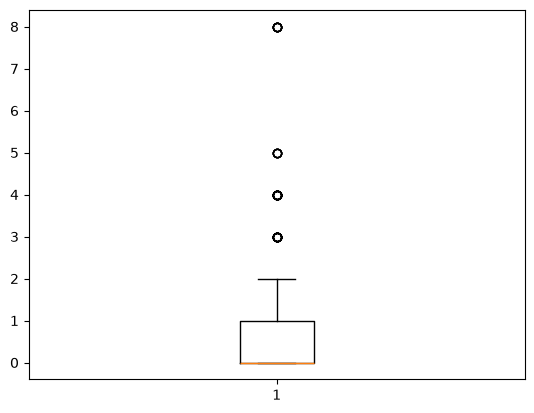

In [13]:
plt.boxplot(df["SibSp"])
plt.show()

In [14]:
###DATA a predecir
y = df["Survived"]
X = df.drop("Survived", axis=1)
X.describe()

,Pclass,Age,SibSp,Parch,Fare,is_miss,is_mr,is_mrs,is_master,is_nobility,...,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,...,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,29.843003,0.523008,0.381594,32.204208,0.208754,0.602694,0.143659,0.044893,0.003367,...,0.035915,0.015713,0.011223,0.001122,0.195286,0.052750,0.086420,0.188552,0.722783,2.860831
std,0.836071,13.271043,1.102743,0.806057,49.693429,0.406647,0.489615,0.350940,0.207186,0.057961,...,0.186182,0.124431,0.105403,0.033501,0.396644,0.223659,0.281141,0.391372,0.447876,0.750088
min,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,3.000000,30.000000,0.000000,0.000000,14.454200,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
75%,3.000000,35.873874,1.000000,0.000000,31.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [15]:
from sklearn.model_selection import train_test_split

In [16]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)
print(type(X_train))


<class 'pandas.DataFrame'>


In [40]:

#X_train = X_train.to_numpy()
X_train = X.to_numpy()
y_train= y.to_numpy()
#X_test = X_test.to_numpy()
print(type(X_train))


<class 'numpy.ndarray'>


In [18]:
print(np.mean(X_train[:, :4], axis=0)) 
print(np.max(X_train[:, :4], axis=0))
print(np.min(X_train[:, :4], axis=0))
print(np.median(X_train[:, :4], axis=0))


[ 2.32303371 29.79801532  0.56460674  0.37640449]
[ 3. 80.  8.  6.]
[1.   0.42 0.   0.  ]
[ 3. 31.  0.  0.]


In [19]:
print(X_train.shape)
print(y_train.shape)

print(np.max(X_train), np.min(X_train))
print(np.max(y_train), np.min(y_train))

print(X_train[:5])
print(y_train[0])

(712, 27)
(712,)
512.3292 0.0
1 0
[[ 3.         47.          0.          0.          9.          0.
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          1.          3.        ]
 [ 3.         23.          0.          0.          7.55        1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          1.          0.
   0.          0.          0.          1.          0.          0.
   0.          1.          3.        ]
 [ 3.         29.          0.          0.          9.4833      0.
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          1.          0.          0.
   0.          1.          3.        ]
 [ 2.         23.          0.          0.         15.0458

In [20]:
for i in range(X_train.shape[1]):
    col_max = np.max(X_train[:, i])
    col_min = np.min(X_train[:, i])
    
    print(i, "min:", col_min, "max:", col_max)

0 min: 1.0 max: 3.0
1 min: 0.42 max: 80.0
2 min: 0.0 max: 8.0
3 min: 0.0 max: 6.0
4 min: 0.0 max: 512.3292
5 min: 0.0 max: 1.0
6 min: 0.0 max: 1.0
7 min: 0.0 max: 1.0
8 min: 0.0 max: 1.0
9 min: 0.0 max: 1.0
10 min: 0.0 max: 1.0
11 min: 0.0 max: 1.0
12 min: 0.0 max: 1.0
13 min: 0.0 max: 1.0
14 min: 0.0 max: 1.0
15 min: 0.0 max: 1.0
16 min: 0.0 max: 1.0
17 min: 0.0 max: 1.0
18 min: 0.0 max: 1.0
19 min: 0.0 max: 1.0
20 min: 0.0 max: 1.0
21 min: 0.0 max: 1.0
22 min: 0.0 max: 1.0
23 min: 0.0 max: 1.0
24 min: 0.0 max: 1.0
25 min: 0.0 max: 1.0
26 min: 0.0 max: 7.0


In [21]:
i=0
for vector in X_test:
    i+=1
print(y_train[:5])
#reset_index
y_train=y_train.reset_index(drop=True)

873    0
649    1
713    0
135    0
639    0
Name: Survived, dtype: int64


In [22]:
import bisect
import statistics

In [23]:
from dataclasses import dataclass
from dataclasses import field

@dataclass
class Desicion:
    caracteristica_index: int
    corte:float
    gini_res: float=None

        
@dataclass
class Node:
    desicion:Desicion=None
    indices_izquierda:list[int]=field(default_factory=list)
    indices_derecha:list[int]=field(default_factory=list)
    prediction:int=None
    left=None
    right=None

    

def get_gini_pond(n_unos,total_grupo,total_global):
    return(2*n_unos*(total_grupo-n_unos))/(total_grupo*total_global)
    
def gin_izq_der(indices_derecha,indices_izquierda,active_indexes,y_train):
    total_izq=len(indices_izquierda)
    total_der=len(indices_derecha)
    total=len(active_indexes)
    unos_izq=sum(y_train[indices_izquierda])
    unos_der=sum(y_train[indices_derecha])
    gini_pond_izq=get_gini_pond(unos_izq,total_izq,total)
    gini_pond_der=get_gini_pond(unos_der,total_der,total)
    return gini_pond_der+gini_pond_izq

def get_best_split(data,active_indexes,y_train, index):
    #print(active_indexes)
    #print(data)
    #print(index)
    sorted_column, indices = zip(*sorted(zip(data[active_indexes].T[index], active_indexes)))
    last_value=sorted_column[0]
    splits=[]
    
    for value in sorted_column[1:]:
        if value != last_value:
            splits.append((value+last_value)/2)
            last_value=value
    if len(splits)==0:
        return None
    min_gin=None
    for i_split,split in enumerate(splits):
        desicion=Desicion(caracteristica_index=index,corte=split)
        nodo=Node(desicion=desicion)
        left_idx = bisect.bisect_right(sorted_column,split)
        nodo.indices_derecha+= indices[left_idx:]
        nodo.indices_izquierda+= indices[:left_idx]
        #for index, value in enumerate(sorted_column):
          
         #   if value > split :
          #      desicion.indices_derecha.append(indices[index])
                
           # else:
            #    desicion.indices_izquierda.append(indices[index])
                
                
            
                
        gin_calculated=gin_izq_der(indices_derecha=nodo.indices_derecha,indices_izquierda=nodo.indices_izquierda,active_indexes=active_indexes,y_train=y_train)
            
        if min_gin is None or gin_calculated<min_gin:
            nodo.desicion.gini_res=gin_calculated                                                                                                                                                  
            best_nodo=nodo
            
            min_gin=gin_calculated
   
    return best_nodo
def get_best_characterictic(X_train,y_train,active_indexes,rng,max_features):
        min_caracteristic_gin=None
        best_characteristic=None
        features=rng.choice(
                len(X_train[0]),
                size=max_features,
                replace=False
                    )   
        indices_features=features
     
        #Iterate over columns   
        for index in indices_features:
           
            best_desicion=get_best_split(X_train,active_indexes,y_train,index)
            if  not best_desicion is None and (min_caracteristic_gin is None or best_desicion.desicion.gini_res<min_caracteristic_gin):
                min_caracteristic_gin= best_desicion.desicion.gini_res
                best_characteristic=best_desicion
        return best_characteristic
            
def build_tree(X_train,y_train,active_indexes,rng,max_features,depth,more_common_value):
    
    if len(active_indexes) == 0:
        raise Exception("Algo salio mal, los indices estan vacios")
    arr_aux=y_train[active_indexes]
    flag_hoja=False
    
    
 
    if depth ==0   or np.all(arr_aux == y_train[active_indexes[0]]) :
        flag_hoja =True
    else:    
        raiz=get_best_characterictic(X_train,y_train, active_indexes,rng,max_features)
    
   
    if flag_hoja or raiz is None:
        
        vals, counts = np.unique(arr_aux, return_counts=True)
    
        # Find all values that match the maximum frequency count
        all_modes = vals[np.argwhere(counts == np.max(counts)).flatten()]
        
        if len(all_modes) != 1:
            pred=more_common_value  
        else:
            pred=int(all_modes[0])
        raiz = Node(prediction=pred )
    else:
        
        raiz.left=build_tree(X_train,y_train,raiz.indices_izquierda,rng,max_features,depth-1,more_common_value)
        raiz.right=build_tree(X_train,y_train,raiz.indices_derecha,rng,max_features,depth-1,more_common_value)
    raiz.indices_izquierda=[]
    raiz.indices_derecha=[]
    return raiz

           
        

In [24]:
class MyForestModel():
    def __init__(self):
        self.forest=[]
    def fit(self,X_train,y_train,depth,max_samples=0.7,n_estimators=30,max_features=5):
        rng = np.random.default_rng(seed=42)
        # Generate random indices with replacement in a grid (num_bootstraps x array_length)
        self.sample_indices = rng.integers(0, len(X_train), size=(n_estimators, int(len(X_train)*max_samples)))
        
           
        #self.features_indices = rng.integers(0, len(X_train[0]), size=(n_estimators, max_features)) 
      
        if sum(y_train) <= int(len(y_train)/2):
            self.common=0
        else:
            self.common=1
       
        for _, all_indices in enumerate(self.sample_indices):
               
            rng_tree = np.random.default_rng(rng.integers(2**32))
            
            self.forest.append(build_tree(X_train,y_train,all_indices,rng_tree,max_features,depth,self.common))
        
    def predict(self,X_test):
        y_predict=[]
        for registro in X_test:
            votacion=[]
            for arbol in self.forest:
                nodo= arbol
                while nodo.prediction == None:
    
                    if registro[nodo.desicion.caracteristica_index] <= nodo.desicion.corte:
                        nodo=nodo.left
                        
                    else:
                        nodo=nodo.right
                    
                votacion.append(nodo.prediction)
            moda =  statistics.multimode(votacion)
            if len(moda)!= 1:
                y_predict.append(self.common)
            else:
                y_predict.append(moda[0])
            
        return y_predict
    def print_arbol(self, nombres):

        def imprimir(nodo, prefijo="", es_izquierdo=True):
    
            if nodo is None:
                return
    
            # Hoja
            if nodo.prediction is not None:
                print(
                    prefijo +
                    ("├── " if es_izquierdo else "└── ") +
                    f"Predicción: {nodo.prediction}"
                )
                return
    
            nombre = nombres[nodo.desicion.caracteristica_index]
    
            print(
                prefijo +
                ("├── " if es_izquierdo else "└── ") +
                f"{nombre} <= {nodo.desicion.corte:.4f}"
                f" (Gini={nodo.desicion.gini_res:.4f})"
            )
    
            imprimir(
                nodo.left,
                prefijo + ("│   " if es_izquierdo else "    "),
                True
            )
    
            imprimir(
                nodo.right,
                prefijo + ("│   " if es_izquierdo else "    "),
                False
            )

        imprimir(self.forest[0], "", False)
        

In [41]:
model = MyForestModel()
model.fit(X_train,y_train,depth=3,max_samples=0.7,n_estimators=100,max_features=8)
model.print_arbol(df.columns.tolist()[1:])
    
        
    
        
    

└── is_mr <= 0.5000 (Gini=0.3143)
    ├── is_Southampton <= 0.5000 (Gini=0.3938)
    │   ├── is_Queenstown <= 0.5000 (Gini=0.1886)
    │   │   ├── Predicción: 1
    │   │   └── Predicción: 1
    │   └── first_10k <= 0.5000 (Gini=0.3679)
    │       ├── Predicción: 1
    │       └── Predicción: 0
    └── Age <= 60.5000 (Gini=0.2393)
        ├── Fare <= 26.2688 (Gini=0.2336)
        │   ├── Predicción: 0
        │   └── Predicción: 0
        └── Predicción: 0


In [27]:
print(X_test)

[[ 2.         52.          0.         ...  0.          1.
   3.        ]
 [ 3.         22.02666667  0.         ...  0.          0.
   3.        ]
 [ 1.         51.          1.         ...  0.          1.
   3.        ]
 ...
 [ 3.         30.          0.         ...  0.          1.
   3.        ]
 [ 2.         41.          0.         ...  0.          1.
   3.        ]
 [ 3.         38.          1.         ...  0.          1.
   3.        ]]


In [28]:
y_pred=model.predict(X_test)
y_test_aux=y_test.T
print(y_pred)
y_test_list= list(y_test_aux)
print(y_test_list)

[0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0]
[0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0,

In [29]:


VP=0
VN=0
FP=0
FN=0

for index, valor in enumerate(y_pred):
   
    if valor== y_test_list[index]:
        if valor==1:
            VP+=1
        else:
            VN+=1
    else:
        if valor ==1:
            FP+=1
        else:
            FN+=1
m_confusion= np.array([[VN,FP],
                       [FN,VP]]) 
accuarcy= (VP+VN)/(VP+VN+FP+FN)
print(accuarcy)
 
    

0.8547486033519553


In [30]:
accuarcy= (VP+VN)/(VP+VN+FP+FN)
print(accuarcy)#¿Qué porcentaje de todas las predicciones fueron correctas?
precision= VP/(VP+FP)
print(precision)#De todo lo que el modelo dijo que era positivo, ¿cuánto realmente era positivo?
recall= VP/(VP+FN)
print(recall)#De todos los positivos reales, ¿cuántos encontró el modelo?
f1_score=2*((precision*recall)/(precision+recall))
print(f1_score)
specificity=VN/(VN+FP)#De todos los positivos reales, ¿cuántos encontró el modelo?
print(specificity)

0.8547486033519553
0.8676470588235294
0.7763157894736842
0.8194444444444444
0.912621359223301


In [32]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [33]:
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))


[[94  9]
 [17 59]]
0.8547486033519553
0.8676470588235294
0.7763157894736842
0.8194444444444444


In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       103
           1       0.87      0.78      0.82        76

    accuracy                           0.85       179
   macro avg       0.86      0.84      0.85       179
weighted avg       0.86      0.85      0.85       179



In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    max_features=8,
    bootstrap=True,
    max_samples=0.7,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))



Accuracy: 0.8435754189944135


              precision    recall  f1-score   support

           0       0.80      0.88      0.84       103
           1       0.82      0.70      0.75        76

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.80      0.80       179



In [42]:
#para el ejercicio de kaggle utilizare mi modelo...
df_ori = pd.read_csv("./DATASETS/titanic/test.csv",sep=",")
df=df_ori.drop(columns=['PassengerId'])
df[['is_miss',"is_mr","is_mrs","is_master","is_nobility","is_rev","is_dr","is_french","is_soldier","is_captain","is_prepaid","is_naviera",
   "is_agent_ca","is_agent_a","is_agent_sc","is_wc","is_special","first_10k","super_cabin","is_Queenstown","is_Cherbourg","is_Southampton","level"]] = df.apply(get_extra_data, axis=1,result_type="expand",cabinas_premium=cabinas_premium)

just_ladys=df[df['is_miss'] == 1]
just_married_ladies=df[df['is_mrs'] == 1]
just_mr= df[df['is_mr'] == 1]
mean_age_ladies = just_ladys["Age"].mean()
mean_age_mr=just_mr["Age"].mean()
mean_age_married_ladies=just_married_ladies["Age"].mean()
print(mean_age_ladies,mean_age_married_ladies,mean_age_mr)
df["Age"]= df.apply(correct_age, axis=1,mean_ladies=mean_age_ladies,mean_married=mean_age_married_ladies,mean_mr=mean_age_mr)

df.tail()


21.774843750000002 38.904761904761905 32.340425531914896


,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,...,is_agent_a,is_agent_sc,is_wc,is_special,first_10k,super_cabin,is_Queenstown,is_Cherbourg,is_Southampton,level
413,3,"Spector, Mr. Woolf",male,32.340426,0,0,A.5. 3236,8.0500,NaN,S,...,1,0,0,0,1,0,0,0,1,3
414,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,PC 17758,108.9000,C105,C,...,0,0,0,0,0,0,0,1,0,2
415,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,...,0,0,0,0,0,0,0,0,1,3
416,3,"Ware, Mr. Frederick",male,32.340426,0,0,359309,8.0500,NaN,S,...,0,0,0,0,0,0,0,0,1,3
417,3,"Peter, Master. Michael J",male,6.000000,1,1,2668,22.3583,NaN,C,...,0,0,0,0,1,0,0,1,0,3


In [43]:
df=df.drop(columns=['Name',"Sex","Ticket","Cabin","Embarked","is_captain"])
print(df.columns)
####Drop carcteristics n-1
#df=df.drop(columns=["is_mr","is_Southampton"])


X = df.to_numpy()
y_pred=model.predict(X)


print(y_pred)


Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'is_miss', 'is_mr', 'is_mrs',
       'is_master', 'is_nobility', 'is_rev', 'is_dr', 'is_french',
       'is_soldier', 'is_prepaid', 'is_naviera', 'is_agent_ca', 'is_agent_a',
       'is_agent_sc', 'is_wc', 'is_special', 'first_10k', 'super_cabin',
       'is_Queenstown', 'is_Cherbourg', 'is_Southampton', 'level'],
      dtype='str')
[0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0,

[0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 

In [44]:
with open("./respuesta.csv","w") as fo:
    fo.write("PassengerId,Survived\n")
    for index,id_p in enumerate(df_ori['PassengerId']):
        fo.write(f"{id_p},{y_pred[index]}\n")
    